# County population by census year (IPUMS NHGIS API)

This notebook shows how to request **nominal** county-level **total population** from IPUMS NHGIS using the official Python client (`ipumspy`), load the result into pandas, save a wide CSV (one row per county, census years as columns), **aggregate counties to state totals**, and plot **national and state** time series.

## Prerequisites

1. **NHGIS registration** (required to *submit* extracts, not just browse metadata). Log in at [NHGIS](https://www.nhgis.org/) and complete registration if prompted. If the API returns *“not registered to IPUMS nhgis”*, use [NHGIS registration / renewal](https://uma.pop.umn.edu/nhgis/registration/new).
2. An API key from [account.ipums.org/api_keys](https://account.ipums.org/api_keys), pasted into the first code cell (`IPUMS_API_KEY`).

## Data choice

NHGIS **time series table [A00](https://www.nhgis.org/time-series-tables)** (*Total Population*, **nominal** geographic integration) links comparable total-population counts across decennial censuses at the **state–county** level. Each row is an NHGIS county unit; a given census column is non-empty when that unit appears in that census (per NHGIS nominal linkage). To approximate **current** counties, we keep counties with non-missing **2020** population (you can change this rule if you prefer another baseline).

References: [IPUMS API overview](https://developer.ipums.org/docs/v2/apiprogram/), [NHGIS](https://www.nhgis.org/), [ipumspy aggregate extracts](https://ipumspy.readthedocs.io/en/latest/ipums_api/ipums_api_aggregate/index.html).

In [1]:
import os
import re
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from ipumspy import (
    AggregateDataExtract,
    IpumsApiClient,
    TimeSeriesTable,
)
from ipumspy.api.metadata import TimeSeriesTableMetadata

# Project folder = directory that contains this notebook (cursor_census), not necessarily cwd
_NB = "nhgis_county_population_via_api.ipynb"


def _notebook_project_dir() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / _NB).is_file():
            return p
        if (p / "cursor_census" / _NB).is_file():
            return p / "cursor_census"
    for extra in (cwd / "cursor_census", cwd / "Week2" / "cursor_census"):
        if (extra / _NB).is_file():
            return extra.resolve()
    return cwd


OUT_DIR = _notebook_project_dir()
print("OUT_DIR (cursor_census project):", OUT_DIR)
DATA_DIR = OUT_DIR / "data"
DATA_DIR.mkdir(exist_ok=True)

# --- Extract scope (change in one place) ---
# List = verification run (small, minutes). None = all decennial years 1790–2020 (slow, 30–90+ min).
A00_YEARS = [2000, 2010, 2020]
# A00_YEARS = None  # uncomment for full county history

_stem = "a00_verify" if A00_YEARS else "a00_full"
ZIP_PATH = DATA_DIR / f"nhgis_county_{_stem}.zip"
CSV_OUT = DATA_DIR / f"county_population_{_stem}.csv"

# Private repo: paste your key from https://account.ipums.org/api_keys
IPUMS_API_KEY = "59cba10d8a5da536fc06b59df1d9eca2d6114582ac1c002722d948da"

client = IpumsApiClient(IPUMS_API_KEY)


OUT_DIR (cursor_census project): /home/student/suwaraich


/opt/jupyterhub/jupyter_env/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Download an existing NHGIS extract by ID

If you already have extracts on your [IPUMS NHGIS](https://www.nhgis.org/) account, you can pull one by **extract number** (shown in the website’s extract history) into **`cursor_census/downloads/`** (next to this notebook). The job must be **finished** on the server (`status` is `completed`) before `download_extract` will work.

Set `EXISTING_EXTRACT_ID` below (e.g. `6`). After a successful download, `ZIP_PATH` is updated so the **Load CSV** cells can read that file.

In [2]:
# NHGIS extract number from your account (see NHGIS → My Data / extract history)
EXISTING_EXTRACT_ID = 6

DOWNLOADS_DIR = OUT_DIR / "downloads"
DOWNLOADS_DIR.mkdir(parents=True, exist_ok=True)

st = client.extract_status(EXISTING_EXTRACT_ID, collection="nhgis")
print(f"NHGIS extract {EXISTING_EXTRACT_ID} status: {st!r}")

if st != "completed":
    print(
        "ipumspy only downloads when status is 'completed'. "
        "If the extract is still building, wait and re-run this cell."
    )
else:
    client.download_extract(
        EXISTING_EXTRACT_ID,
        collection="nhgis",
        download_dir=str(DOWNLOADS_DIR),
    )
    print("Downloaded to:", DOWNLOADS_DIR.resolve())
    for f in sorted(DOWNLOADS_DIR.glob("*.zip")):
        print(" ", f.name)
    # Point later notebook cells at the newest zip in downloads
    newest = max(DOWNLOADS_DIR.glob("*.zip"), key=lambda p: p.stat().st_mtime, default=None)
    if newest is not None:
        ZIP_PATH = newest
        print("ZIP_PATH set for load steps:", ZIP_PATH)

NHGIS extract 6 status: 'completed'
Downloaded to: /home/student/suwaraich/downloads
  nhgis0006_csv.zip
ZIP_PATH set for load steps: /home/student/suwaraich/downloads/nhgis0006_csv.zip


## Optional: inspect metadata for table A00

Confirms available geographic levels and census years before submitting an extract.

In [3]:
# TimeSeriesTableMetadata requires both collection and table name (see ipumspy docs).
meta = client.get_metadata(TimeSeriesTableMetadata(collection="nhgis", name="A00"))
print("Description:", meta.description)
print("Geographic integration:", meta.geographic_integration)


def _pluck_names(items):
    if not items:
        return []
    if isinstance(items[0], dict):
        return [x.get("name", x.get("description", x)) for x in items]
    return list(items)


print("Geographic levels:", _pluck_names(meta.geog_levels))
years = _pluck_names(meta.years)
print("Years (count):", len(years), "| sample:", years[:5], "...", years[-3:])

Description: Total Population
Geographic integration: Nominal
Geographic levels: ['nation', 'state', 'county']
Years (count): 24 | sample: ['1790', '1800', '1810', '1820', '1830'] ... ['2000', '2010', '2020']


## Submit extract, wait, and download

If you see **`IpumsAPIAuthenticationError` ... not registered to IPUMS nhgis**, your account must be registered for NHGIS (link in the introduction). Metadata can succeed while extract submission is blocked until registration is active.

### Scope: verify first, full history later

The first code cell sets **`A00_YEARS`**. Default is **`[2000, 2010, 2020]`** — enough to test download, CSV, and plots quickly. When that works, set **`A00_YEARS = None`** for the full nominal county series (1790–2020); that job is **much** larger.

### How long does the extract take?

**Verify (3 years):** often **~5–20 minutes** (varies with queue). **Full history:** often **30–90+ minutes**. Status is printed every minute.

- **A00** at **county**: total population, nominal integration; years come from `A00_YEARS`.
- `tst_layout="time_by_column_layout"`: time points as separate columns (default).
- `data_format="csv_header"`: include the descriptive second header row (we skip it when reading into pandas).

In [4]:
import time

if A00_YEARS is None:
    _tst = TimeSeriesTable("A00", geog_levels=["county"])
    _desc = "County A00 nominal, all census years (full)"
else:
    _tst = TimeSeriesTable("A00", geog_levels=["county"], years=A00_YEARS)
    _desc = f"County A00 nominal, years {A00_YEARS} (verify)"

extract = AggregateDataExtract(
    collection="nhgis",
    description=_desc,
    time_series_tables=[_tst],
    data_format="csv_header",
    tst_layout="time_by_column_layout",
)

submitted = client.submit_extract(extract)
print(
    f"Submitted extract #{submitted.extract_id} — {_desc}. Polling status..."
)

# wait_for_extract() is silent; poll so you see queued/started/completed
poll_sec = 60
timeout_sec = 45 * 60 if A00_YEARS else 4 * 3600  # verify ~45 min max; full up to 4 h
t0 = time.monotonic()
while True:
    status = client.extract_status(submitted)
    elapsed = time.monotonic() - t0
    print(f"[{elapsed / 60:6.1f} min] status={status!r}")
    if status == "completed":
        break
    if status == "failed":
        raise RuntimeError("Extract failed on the IPUMS server; check your account email or try a smaller request.")
    if elapsed > timeout_sec:
        raise TimeoutError(
            f"Still not completed after {timeout_sec / 3600:.1f} h — try fewer years or check https://www.nhgis.org/"
        )
    time.sleep(poll_sec)

client.download_extract(submitted, str(ZIP_PATH))
print("Saved:", ZIP_PATH)

Submitted extract #11 — County A00 nominal, years [2000, 2010, 2020] (verify). Polling status...
[   0.0 min] status='published'


KeyboardInterrupt: 

## Load CSV from the zip

NHGIS zips contain a `*_csv/` folder with one or more `.csv` files. We take the first `*_county*.csv` (or any `.csv` in that folder if needed).

In [5]:
def load_nhgis_county_csv(zip_path: Path) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path, "r") as zf:
        names = zf.namelist()
        csv_candidates = [
            n for n in names
            if n.lower().endswith(".csv") and "_csv/" in n.replace("\\", "/")
        ]
        county_csv = [n for n in csv_candidates if "county" in n.lower()]
        chosen = (county_csv or csv_candidates)[0]
        with zf.open(chosen) as f:
            # csv_header: row 0 = names, row 1 = descriptions (skip row 1)
            df = pd.read_csv(f, header=0, skiprows=[1], low_memory=False)
    return df


raw = load_nhgis_county_csv(ZIP_PATH)
raw.head()

,GISJOIN,STATE,STATEFP,STATENH,COUNTY,COUNTYFP,COUNTYNH,A00AA1790,A00AA1800,A00AA1810,...,A00AA1930,A00AA1940,A00AA1950,A00AA1960,A00AA1970,A00AA1980,A00AA1990,A00AA2000,A00AA2010,A00AA2020
0,G0100010,Alabama,1.0,10,Autauga County,1.0,10,NaN,NaN,NaN,...,19694.0,20977.0,18186.0,18739.0,24460.0,32259.0,34222.0,43671.0,54571.0,58805.0
1,G0100015,Alabama,1.0,10,Baker County,NaN,15,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,G0100030,Alabama,1.0,10,Baldwin County,3.0,30,NaN,NaN,NaN,...,28289.0,32324.0,40997.0,49088.0,59382.0,78556.0,98280.0,140415.0,182265.0,231767.0
3,G0100050,Alabama,1.0,10,Barbour County,5.0,50,NaN,NaN,NaN,...,32425.0,32722.0,28892.0,24700.0,22543.0,24756.0,25417.0,29038.0,27457.0,25223.0
4,G0100055,Alabama,1.0,10,Benton County,NaN,55,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Wide table: identifier columns + census year columns

NHGIS names data columns with a table/series prefix and a 4-digit year suffix (e.g. `A00AA2020`). We rename those columns to the census year string. Identifier columns are those that do not match that pattern.

In [6]:
YEAR_SUFFIX = re.compile(r"^(?P<prefix>.+?)(?P<year>\d{4})$")


def split_id_and_year_columns(columns):
    id_cols = []
    year_map = {}
    for c in columns:
        s = str(c).strip()
        m = YEAR_SUFFIX.match(s)
        if m and 1790 <= int(m.group("year")) <= 2100:
            year_map[s] = m.group("year")
        else:
            id_cols.append(s)
    return id_cols, year_map


id_cols, year_map = split_id_and_year_columns(raw.columns)
wide = raw.rename(columns=year_map)
year_cols = sorted(year_map.values(), key=int)

# Keep rows that have 2020 data = proxy for "current" county set in NHGIS nominal file
if "2020" in wide.columns:
    mask = wide["2020"].notna() & (wide["2020"].astype(str).str.strip() != "")
    wide_current = wide.loc[mask].copy()
else:
    wide_current = wide.copy()

# Numeric population columns
for y in year_cols:
    wide_current[y] = pd.to_numeric(wide_current[y], errors="coerce")

out = wide_current[id_cols + year_cols]
out.to_csv(CSV_OUT, index=False)
print("Wrote", CSV_OUT, "shape", out.shape)

Wrote /home/student/suwaraich/data/county_population_a00_verify.csv shape (3221, 31)


## State population time series (counties summed to state)

Each county row is grouped by **`STATE`** (and **`STATEFP`**) and the census-year columns are **summed**, giving one population per state per year. The next cell plots **every** state/territory row in `state_pop` on one chart (lines are color-cycled; there is no legend because there are too many series).

In [8]:
# Group counties → state totals (sum population in each census year)
_state_group_cols = [c for c in ("STATE", "STATEFP") if c in out.columns]
if not _state_group_cols:
    raise ValueError("Expected STATE / STATEFP columns after loading NHGIS county CSV")

state_pop = out.groupby(_state_group_cols, dropna=False, as_index=False)[year_cols].sum()
STATE_POP_CSV = DATA_DIR / "state_population_from_counties.csv"
state_pop.to_csv(STATE_POP_CSV, index=False)
print("Wrote", STATE_POP_CSV, state_pop.shape)
state_pop.head()

Wrote /home/student/suwaraich/data/state_population_from_counties.csv (52, 26)


,STATE,STATEFP,1790,1800,1810,1820,1830,1840,1850,1860,...,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
0,Alabama,1.0,0.0,0.0,0.0,135378.0,309527.0,576496.0,752918.0,964201.0,...,2646248.0,2832961.0,3061743.0,3266740.0,3444165.0,3893888.0,4040587.0,4447100.0,4779736.0,5024279.0
1,Alaska,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,243097.0,362772.0,516595.0,593443.0,693136.0,733391.0
2,Arizona,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,435573.0,499261.0,749587.0,1302161.0,1770900.0,2718215.0,3665228.0,5130632.0,6392017.0,7151502.0
3,Arkansas,5.0,0.0,0.0,0.0,0.0,0.0,97574.0,209897.0,435450.0,...,1854482.0,1949387.0,1909511.0,1786272.0,1923295.0,2286435.0,2350725.0,2673400.0,2915918.0,3011524.0
4,California,6.0,0.0,0.0,0.0,0.0,0.0,0.0,92597.0,378191.0,...,5677251.0,6907387.0,10586223.0,15717204.0,19953134.0,23667902.0,29760021.0,33871648.0,37253956.0,39538223.0


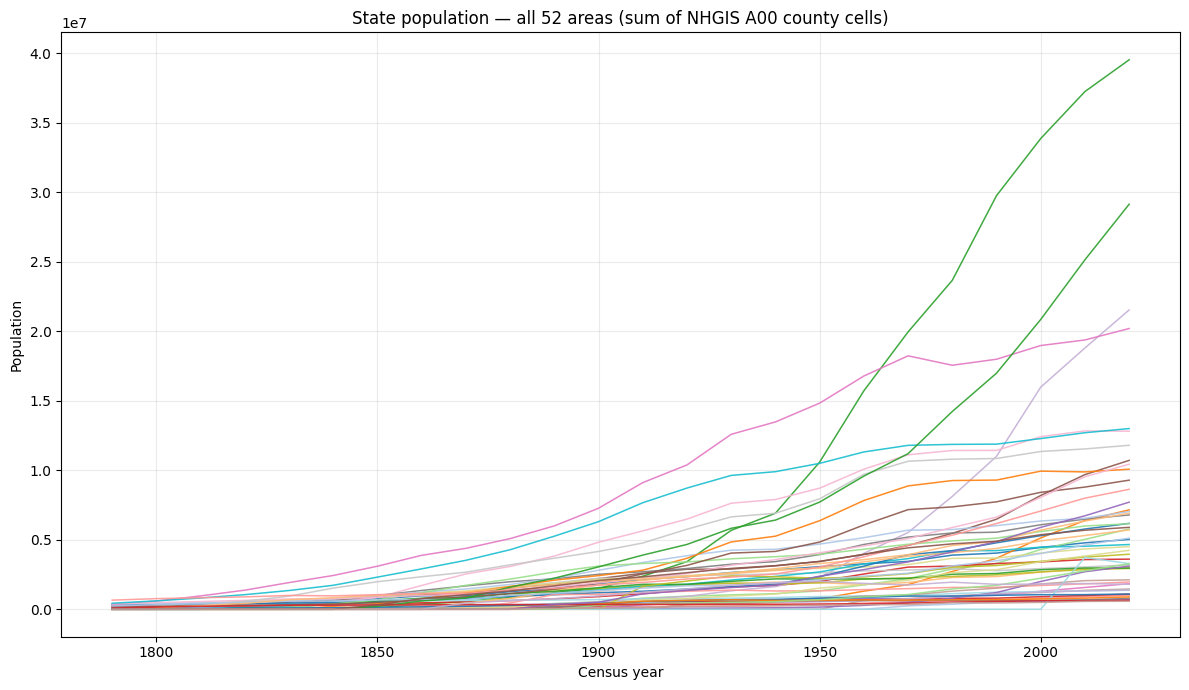

Saved /home/student/suwaraich/data/state_population_timeseries.png


In [13]:
years_int = [int(y) for y in year_cols]
n_states = len(state_pop)
fig, ax = plt.subplots(figsize=(12, 7))

for i, (_, row) in enumerate(state_pop.iterrows()):
    vals = pd.to_numeric(row[year_cols], errors="coerce")
    color = plt.cm.tab20(i % 20 / 20.0)
    ax.plot(years_int, vals.values, color=color, linewidth=1.1, alpha=0.9)

ax.set_title(
    f"State population — all {n_states} areas (sum of NHGIS A00 county cells)"
)
ax.set_xlabel("Census year")
ax.set_ylabel("Population")
ax.grid(True, alpha=0.25)
plt.tight_layout()
state_fig_path = DATA_DIR / "state_population_timeseries.png"
fig.savefig(state_fig_path, dpi=150)
plt.show()
print("Saved", state_fig_path)

**Growth extremes.** Percent change from the **first** to the **last** census year in `year_cols` is computed for each state row in `state_pop`. The **three smallest** and **three largest** growth rates are plotted on one figure (six labeled lines). The figure is saved as `state_growth_extremes.png` under `DATA_DIR`.

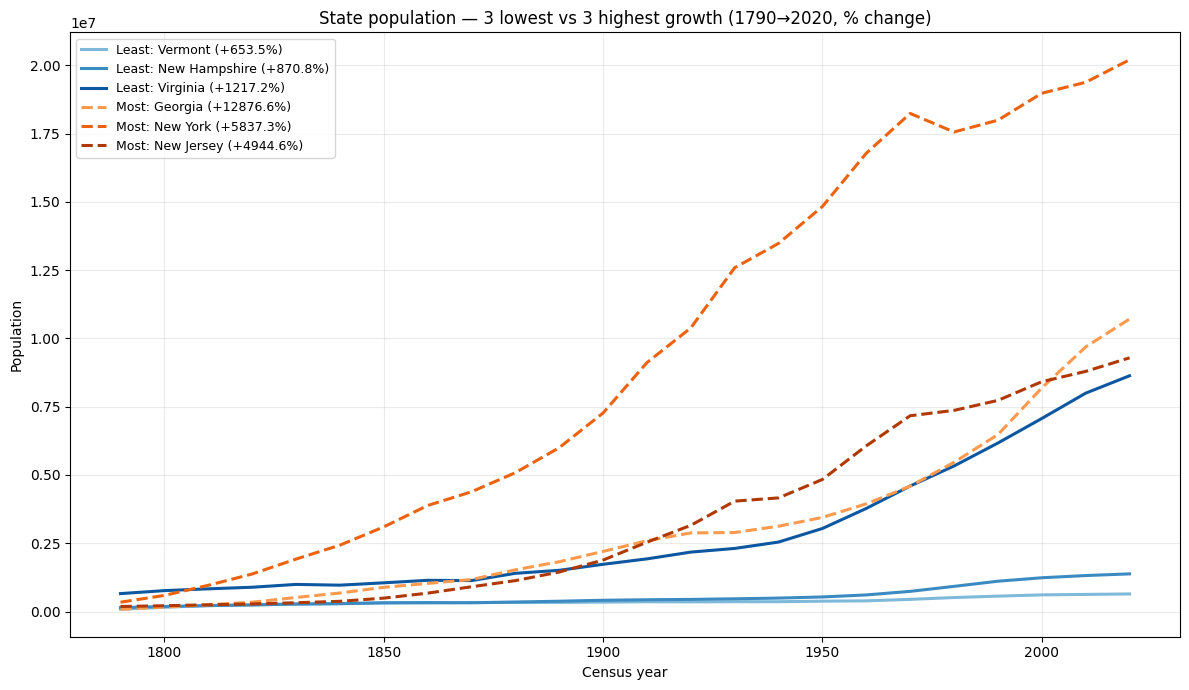

Saved /home/student/suwaraich/data/state_growth_extremes.png

Lowest growth:
         STATE  pct_growth
      Vermont  653.538159
New Hampshire  870.781330
     Virginia 1217.226945

Highest growth:
      STATE   pct_growth
   Georgia 12876.580898
  New York  5837.335301
New Jersey  4944.555472


In [15]:
import numpy as np

first_y, last_y = year_cols[0], year_cols[-1]
years_int = [int(y) for y in year_cols]

sp = state_pop.copy()
first_pop = pd.to_numeric(sp[first_y], errors="coerce")
last_pop = pd.to_numeric(sp[last_y], errors="coerce")
sp["pct_growth"] = ((last_pop - first_pop) / first_pop * 100.0).where(first_pop > 0)
sp = sp.dropna(subset=["pct_growth"])

least3 = sp.nsmallest(3, "pct_growth")
most3 = sp.nlargest(3, "pct_growth")

fig, ax = plt.subplots(figsize=(12, 7))
colors_least = plt.cm.Blues(np.linspace(0.45, 0.85, 3))
colors_most = plt.cm.Oranges(np.linspace(0.45, 0.85, 3))

for i, (_, row) in enumerate(least3.iterrows()):
    vals = pd.to_numeric(row[year_cols], errors="coerce")
    lab = f"{row['STATE']} ({row['pct_growth']:+.1f}%)"
    ax.plot(years_int, vals.values, color=colors_least[i], linewidth=2.2, label=f"Least: {lab}")

for i, (_, row) in enumerate(most3.iterrows()):
    vals = pd.to_numeric(row[year_cols], errors="coerce")
    lab = f"{row['STATE']} ({row['pct_growth']:+.1f}%)"
    ax.plot(years_int, vals.values, color=colors_most[i], linewidth=2.2, linestyle="--", label=f"Most: {lab}")

ax.set_title(
    f"State population — 3 lowest vs 3 highest growth ({first_y}→{last_y}, % change)"
)
ax.set_xlabel("Census year")
ax.set_ylabel("Population")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
growth_fig_path = DATA_DIR / "state_growth_extremes.png"
fig.savefig(growth_fig_path, dpi=150)
plt.show()
print("Saved", growth_fig_path)
print("\nLowest growth:\n", least3[["STATE", "pct_growth"]].to_string(index=False))
print("\nHighest growth:\n", most3[["STATE", "pct_growth"]].to_string(index=False))

## Graphical summary: U.S. total population by census year

Sum population across counties for each census column (ignoring NaNs).

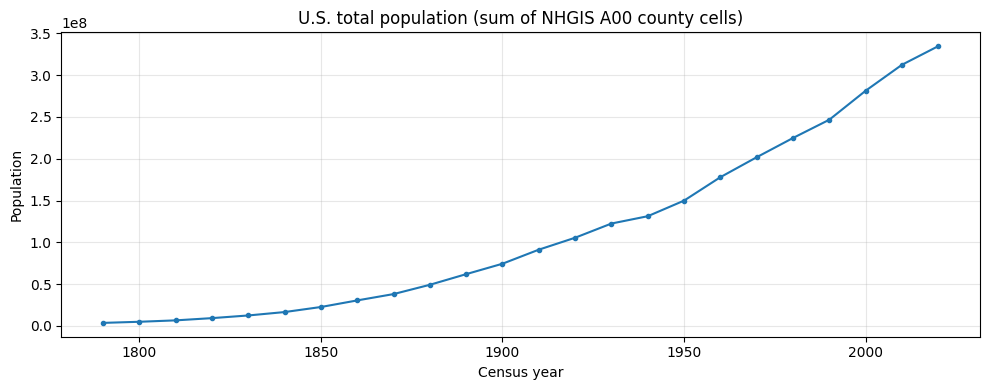

Saved /home/student/suwaraich/data/us_total_population_timeseries.png


In [7]:
totals = out[year_cols].sum(skipna=True)
years_int = [int(y) for y in totals.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(years_int, totals.values, marker="o", markersize=3)
ax.set_title("U.S. total population (sum of NHGIS A00 county cells)")
ax.set_xlabel("Census year")
ax.set_ylabel("Population")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = DATA_DIR / "us_total_population_timeseries.png"
fig.savefig(fig_path, dpi=150)
plt.show()
print("Saved", fig_path)